# Processamento das imagens

O objetivo desse notebook é selecionar, a partir das imagens obtidas pela caixa, as amostras que serão utilizadas pelo modelo.
Além disso, será gerado um arquivo que vai atuar como um catálogo para rastrear cada amostra com suas caracteristicas.

Para isso, o processamento será dividido nas seguintes etapas:

1. Recortar as áreas com algodão: Remover o fundo e a informação da etiqueta, mantendo o maior retângulo possível, que contenha 100% da amostra do algodão.
2. Criar quadrados: Com base nas áreas de algodão recortadas, a ideia é gerar quadrados de tamanho 256x256, sendo esses quadrados utilizados pelo modelo.


In [13]:
# Libs
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Funções úteis

def plotar_imagens(plots, colunas = 5):
    linhas = len(plots) // colunas + 1
    fig = plt.figure(figsize=(16,linhas*3))
    for i in range(len(plots)):
        plot = list(plots.keys())[i]
        ax = fig.add_subplot(linhas,colunas,i+1)
        ax.imshow(plots.get(plot)[0], **plots.get(plot)[1])
        ax.set_title(plot)
    plt.show()

def thresholding_alpha(imagem):
    alpha_channel = imagem[:,:,3]
    binary_mask = np.where(alpha_channel > 0, 255, 0).astype(np.uint8)
    return binary_mask   


def threshold_media(channel, inverso=False):
    
    tipo = cv2.THRESH_BINARY_INV if inverso else cv2.THRESH_BINARY
    media = np.mean(channel)
    _, image_thresh = cv2.threshold(channel,media,255,tipo)
    return image_thresh

Todas as imagens coletadas possuem resolução de `1080x720` e três bandas (RGB). Os nomes dos arquivos estão organizados da seguinte forma: `{prefixo}_{codigofardinho}.png`, sendo os prefixos distribuidos conforme:

- AM: Luz Amarela
- AB: Luz Amarela e Branca
- BR: Luz Branca

In [15]:
caminho_imagem = '../data/bronze/amostras/AB_00078986195518360989.png'

img = cv2.imread(caminho_imagem)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
img.shape

(720, 1280, 3)

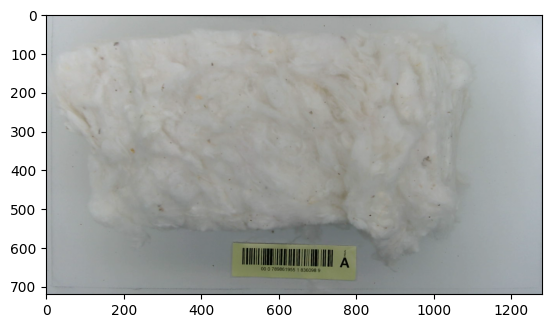

In [16]:
plt.imshow(img) 
plt.show() 

## Recortar as áreas com algodão

### Remover o fundo da imagem

Para isso, será utilizado o modelo Bilateral Reference for High-Resolution Dichotomous Image Segmentation, conforme [documentação](https://github.com/ZhengPeng7/BiRefNet) e [paper](https://arxiv.org/pdf/2401.03407).

A saída desse modelo é uma imagem com 4 dimensões, sendo a quarta a camada de alpha, representando o fundo da imagem.

Abaixo, podemos ver que para o padrão de imagens que temos, esse modelo consegue remover muito bem o fundo da imagem, porém ainda fica a informação da etiqueta, no qual usaremos uma outra ferramenta para fazer a remoção.

Após remover o fundo com o modelo birefnet, criamos uma máscara binária. 

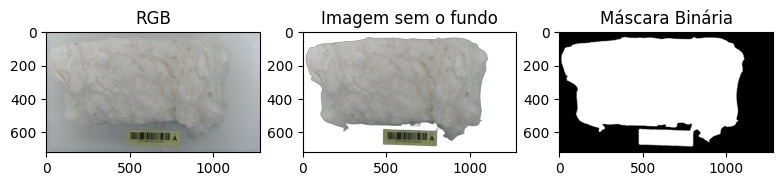

In [18]:
from rembg import remove, new_session

model_name = 'birefnet-dis'
session = new_session(model_name)
img_sem_fundo = remove(img, session=session)
trhesh_maior_zero = thresholding_alpha(img_sem_fundo)

plots = {
    'RGB': [img, {}],
    'Imagem sem o fundo': [img_sem_fundo, {}],
    'Máscara Binária': [trhesh_maior_zero, {'cmap': 'gray'}]

}

plotar_imagens(plots)

### Remover a etiqueta da imagem

Como a máscara para remover o fundo não remove a parte da etiqueta amarela, realizaremos os seguintes passos para remover a etiqueta:

1. Identificar os pixels amarelos contidos dentro de um intervalo pré-estabelecido, que representa a cor amarela;
2. Aplicar uma operação de fechamento morfológico na máscara de pixels amarelos para preencher pequenos buracos e conectar regiões próximas;
3. Identificar e rotular componentes conectados na máscara resultante do fechamento;
4. Criar uma nova máscara, mantendo apenas os componentes conectados com área superior a 500 pixels;
5. Aplicar uma operação de dilatação na máscara filtrada, expandindo as regiões brancas para criar uma área mais ampla ao redor dos objetos detectados.

Após a execução desses passos, temos uma máscara binária que consegue identificar a área com a etiqueta.

In [22]:
# Filtro de amarelo
lower_yellow = np.array([120, 100, 55])
upper_yellow = np.array([150, 150, 110])
mask_yellow = cv2.inRange(img, lower_yellow, upper_yellow)

## Trabalhando com a máscara da etiqueta:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))  # Retangular 5x5
mask_yellow_closed = cv2.morphologyEx(mask_yellow, cv2.MORPH_CLOSE, kernel, iterations=5) # Faz um fechamento em 5 iteração com a máscara de amarelo

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_yellow_closed, connectivity=8) # Pega os componentes conectados
filtered_mask = np.zeros_like(mask_yellow_closed, dtype=np.uint8)

# filtra somente os componentes de tamanho > 500
min_size = 500
for i in range(1, num_labels): 
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_size:
        filtered_mask[labels == i] = 255

# Faz 10 iterações de dilação
y_mask_final = cv2.dilate(filtered_mask, kernel*10, iterations=10)

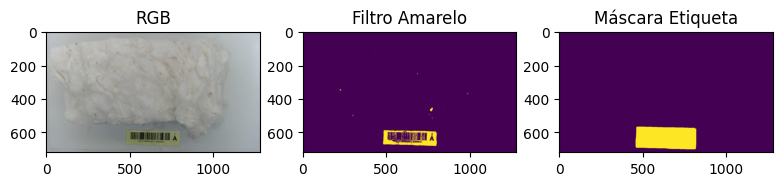

In [24]:
plots = {
    'RGB': [img, {}],
    'Filtro Amarelo': [mask_yellow, {}],
    'Máscara Etiqueta': [y_mask_final, {}]
}

plotar_imagens(plots)

### Juntar as duas máscaras

Criadas as máscaras para remover o fundo e a etiqueta, o próximo passo é juntar as duas, seguindo os passos abaixo:

1.	Subtrair a máscara da etiqueta amarela da máscara de threshold maior que zero, isolando a região de interesse;
2.	Identificar e rotular os componentes conectados na máscara resultante da subtração;
3.	Criar uma nova máscara, removendo componentes conectados com área inferior a 500 pixels para eliminar ruídos;
4.	Aplicar uma operação de erosão na máscara sem ruídos, reduzindo o tamanho dos objetos detectados;
5.	Realizar uma operação de dilatação na máscara erodida, expandindo os objetos para preencher possíveis lacunas;
6.	Desenhar um retângulo preto nas bordas da imagem, criando uma borda de 100 pixels de espessura.

Ao final, a máscara resultante é capaz de selecionar apenas a área com algodão da imagem.

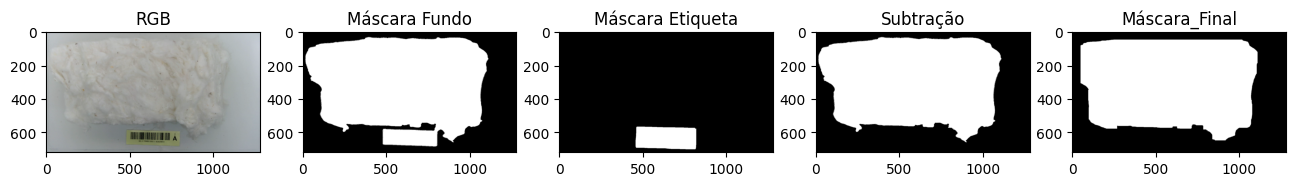

In [26]:
# Subtrair as máscaras
subtract_mask = cv2.subtract(trhesh_maior_zero, y_mask_final)

# Identificar os componentes conectados
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(subtract_mask, connectivity=8)

# Remove o ruído
removed_noise = np.zeros_like(subtract_mask, dtype=np.uint8)
min_size = 500
for i in range(1, num_labels): 
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_size:
        removed_noise[labels == i] = 255

# Erosao
eroded = cv2.erode(removed_noise, kernel, iterations=10)

# Dilação
dilated = cv2.dilate(eroded, kernel, iterations=15)

final_mask = dilated.copy()
cv2.rectangle(final_mask, (0, 0), (final_mask.shape[1] - 1, final_mask.shape[0] - 1), 0, thickness=100)

plots = {
    'RGB': [img, {}],
    'Máscara Fundo': [trhesh_maior_zero, {'cmap': 'gray'}],
    'Máscara Etiqueta': [y_mask_final, {'cmap': 'gray'}],
    'Subtração': [subtract_mask, {'cmap': 'gray'}],
    'Máscara_Final': [final_mask, {'cmap': 'gray'}],
}

plotar_imagens(plots)

### Criar um retângulo com base na máscara final

A partir da máscara final o objetivo é calcular o marior retângulo interior dessa máscara. Para isso segui-se os passos:

1.	Identificar os contornos externos na máscara final, focando nas bordas dos objetos detectados;
2.	Selecionar o maior contorno com base na área, assumindo que este representa o objeto principal de interesse (caso tenha sobrado algum ruído na máscara);
3.	Calcular o maior retângulo interior que se encaixa completamente dentro do contorno selecionado;
4.	Ajustar as coordenadas do retângulo interior, adicionando um deslocamento de 30 pixels para dentro em todas as direções;

No final, tem-se uma imagem retangular com a maior área possível cujo todos os pixels são preenchidos por algodão. Para executar esses passos, foi criada a função `src/functions/cortar_aoi_bg_removido.py` e o script  `src/transformacao_recortar_aoi.py` para automatizar a execução, salvando em `data/silver/amostras_recortadas` os retangulos criados.

Além disso, foi criado o arquivo `data/silver/amostras_recortadas.json`, usado como catálogo para salvar os metadados de cada imagem gerada, para facilitar a manipulação das demais imagens (AM e BR).

Também foi criado uma função para recortar a área de interesse de forma manual, a fim de fazer ajustes pontuais.

(135, 63)


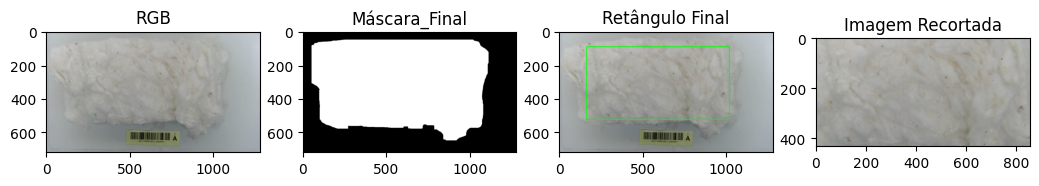

In [35]:
import largestinteriorrectangle as lir
import numpy as np

contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
contour = np.array([largest_contour[:, 0, :]])
inner_bb = lir.lir(contour)

final_mask_rectangle = img.copy()
print(lir.pt1(inner_bb))
desloc = 30
pt1 = tuple([x+desloc for x in lir.pt1(inner_bb)])
pt2 = tuple([x-desloc for x in lir.pt2(inner_bb)])

cv2.rectangle(final_mask_rectangle,pt1, pt2, (0, 255, 0), thickness=3)

img_crop = img[pt1[1]:pt2[1], pt1[0]:pt2[0]]

plots = {
    'RGB': [img, {}],
    'Máscara_Final': [final_mask, {'cmap': 'gray'}],
    'Retângulo Final': [final_mask_rectangle, {}],
    'Imagem Recortada': [img_crop, {}],
}

plotar_imagens(plots)

In [ ]:
import json

with open('../data/silver/amostras_recortadas.json') as f:
    amostras_recortadas = json.load(f)
    

menor_area = min(amostras_recortadas, key=lambda item: item['atributos']['shape_aoi'][0] * item['atributos']['shape_aoi'][1])
menor_altura = min(amostras_recortadas, key=lambda item: item['atributos']['shape_aoi'][0])
menor_largura = min(amostras_recortadas, key=lambda item: item['atributos']['shape_aoi'][1])

print(f"Menor área:\n{menor_area}")
print(f"\nMenor altura:\n{menor_altura}")
print(f"\nMenor largura:\n{menor_largura}")


Menor área:
{'codigo': '00078986195518325995', 'atributos': {'caminho_aoi': 'data/silver/amostras_recortadas/AB_00078986195518325995.png', 'pt1': [380, 41], 'pt2': [990, 368], 'shape_aoi': [327, 610, 3]}}

Menor altura:
{'codigo': '00078986195518338568', 'atributos': {'caminho_aoi': 'data/silver/amostras_recortadas/AB_00078986195518338568.png', 'pt1': [327, 195], 'pt2': [1051, 490], 'shape_aoi': [295, 724, 3]}}

Menor largura:
{'codigo': '00078986195518359310', 'atributos': {'caminho_aoi': 'data/silver/amostras_recortadas/AB_00078986195518359310.png', 'pt1': [516, 56], 'pt2': [1053, 440], 'shape_aoi': [384, 537, 3]}}


O código abaixo faz um ajuste na estrutura do arquivo `amostras_recortadas.json`

In [ ]:
with open('../data/silver/amostras_recortadas.json', 'r') as f:
    amostras_recortadas = json.load(f)

final = []
for amostra in amostras_recortadas:
    caminho_ab = amostra['atributos']['caminho_aoi']
    del amostra['atributos']['caminho_aoi']
    caminhos = {'amostras_aoi': [{'ab': caminho_ab}]}
    final.append({**amostra, **caminhos})

with open('../data/silver/amostras_recortadas.json', 'w') as f:
    json.dump(final, f, ensure_ascii=False, indent=4)

O código abaixo replica o recorte do retângulo nas demais amostras (BR e AM)

In [43]:
import cv2
for amostra in amostras_recortadas:
    # if len(amostra['amostras_aoi']) < 3:
    try:
        codigo = amostra['codigo']
        pt1 = amostra['atributos']['pt1']
        pt2 = amostra['atributos']['pt2']
        prefixo = 'AM'
        img = cv2.imread(f"../data/bronze/amostras/{prefixo}_{codigo}.png")
        img_recortada = img[pt1[1]:pt2[1], pt1[0]:pt2[0]]
        cv2.imwrite(f"../data/silver/amostras_recortadas/{prefixo}_{codigo}.png", img_recortada)
        # amostra['amostras_aoi'].append({'br': f"data/silver/amostras_recortadas/{prefixo}_{codigo}.png"})
    except Exception as e:
        print(e)

# with open('../data/silver/amostras_recortadas.json', 'w') as f:
#     json.dump(amostras_recortadas, f, ensure_ascii=False, indent=4)

## Criar quadrados

As imagens retangulares criadas no passo anterior possuem dimensões diferentes. Essa falta de padrão dificulta o uso em modelos de deep learning, que performam melhor com imagens com as dimensões padronizadas. Dessa forma, optou-se por criar a partir de cada retângulo recortado, quadrados de dimensão `256x256`. Isso além de padronizar as amostras que serão utilizadas pelo modelo, também aumenta o número de amostras, visto que para cada retângulo foram extraídos vários quadrados a fim de cobrir todas as áreas da imagem

In [ ]:
# Cortar as amostras em Quadrado
import math

for amostra in amostras_recortadas:

    codigo = amostra['codigo']
    altura = amostra['atributos']['shape_aoi'][0]
    largura = amostra['atributos']['shape_aoi'][1]

    tamanho_quadrado = 256

    qtd_altura = math.ceil(altura/tamanho_quadrado)
    qtd_largura = math.ceil(largura/tamanho_quadrado)

    quadrados = []
    for i in range(qtd_altura):
        for j in range(qtd_largura): 
            x_ini = 0 + j * tamanho_quadrado
            if (x_ini + tamanho_quadrado) > largura:
                x_ini = largura-tamanho_quadrado

            y_ini = 0 + i * tamanho_quadrado
            if (y_ini + tamanho_quadrado) > altura:
                y_ini = altura-tamanho_quadrado

            x_end = min(x_ini + tamanho_quadrado, largura)
            y_end = min(y_ini + tamanho_quadrado, altura)
            quadrados.append([[x_ini, y_ini], [x_end, y_end]])

    amostra['atributos']['quadrados'] = {}
    amostra['atributos']['quadrados']['qtd'] = len(quadrados)
    amostra['atributos']['quadrados']['pontos'] = quadrados

In [45]:
with open('../data/silver/amostras_recortadas.json', 'r') as f:
    amostras_recortadas = json.load(f)

for amostra in amostras_recortadas:
    prefixo = 'BR'
    codigo = amostra['codigo']
    quadrados = amostra['atributos']['quadrados']['pontos']
    arquivo = f'../data/silver/amostras_recortadas/{prefixo}_{codigo}.png'

    i=1
    for quadrado in quadrados:
        try:
            img = cv2.imread(arquivo)
            img_qdr = img[quadrado[0][1]:quadrado[1][1], quadrado[0][0]:quadrado[1][0]]
            cv2.imwrite(f"../data/silver/amostras_recortadas_quadrado/{prefixo}_{codigo}_{i}.png", img_qdr)
            i+=1 
        except Exception as e:
            print(f"Erro na amostra {codigo}: {e}")

Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518371640: 'NoneType' object is not subscriptable


[ WARN:0@91084.468] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518371640.png'): can't open/read file: check file path/integrity
[ WARN:0@91084.469] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518371640.png'): can't open/read file: check file path/integrity
[ WARN:0@91084.469] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518371640.png'): can't open/read file: check file path/integrity
[ WARN:0@91084.470] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518371640.png'): can't open/read file: check file path/integrity
[ WARN:0@91084.470] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518371640.png'): can't open/read file: check file path/integrity
[ WARN:0@91084.470] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00

Erro na amostra 00078986195518327104: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518327104: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518327104: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518327104: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518327104: 'NoneType' object is not subscriptable
Erro na amostra 00078986195518327104: 'NoneType' object is not subscriptable


[ WARN:0@91087.315] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518327104.png'): can't open/read file: check file path/integrity
[ WARN:0@91087.315] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518327104.png'): can't open/read file: check file path/integrity
[ WARN:0@91087.315] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518327104.png'): can't open/read file: check file path/integrity
[ WARN:0@91087.315] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518327104.png'): can't open/read file: check file path/integrity
[ WARN:0@91087.315] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00078986195518327104.png'): can't open/read file: check file path/integrity
[ WARN:0@91087.315] global loadsave.cpp:268 findDecoder imread_('../data/silver/amostras_recortadas/BR_00

In [46]:
amostras_recortadas

[{'codigo': '00078986195518372326',
  'atributos': {'pt1': [171, 45],
   'pt2': [1065, 493],
   'shape_aoi': [448, 894, 3],
   'quadrados': {'qtd': 8,
    'pontos': [[[0, 0], [256, 256]],
     [[256, 0], [512, 256]],
     [[512, 0], [768, 256]],
     [[638, 0], [894, 256]],
     [[0, 192], [256, 448]],
     [[256, 192], [512, 448]],
     [[512, 192], [768, 448]],
     [[638, 192], [894, 448]]]}},
  'amostras_aoi': [{'ab': 'data/silver/amostras_recortadas/AB_00078986195518372326.png'},
   {'am': 'data/silver/amostras_recortadas/AM_00078986195518372326.png'},
   {'br': 'data/silver/amostras_recortadas/BR_00078986195518372326.png'}]},
 {'codigo': '00078986195518339657',
  'atributos': {'pt1': [304, 157],
   'pt2': [1050, 525],
   'shape_aoi': [368, 746, 3],
   'quadrados': {'qtd': 6,
    'pontos': [[[0, 0], [256, 256]],
     [[256, 0], [512, 256]],
     [[490, 0], [746, 256]],
     [[0, 112], [256, 368]],
     [[256, 112], [512, 368]],
     [[490, 112], [746, 368]]]}},
  'amostras_aoi': [